# NeuroTrace AI — Clean End-to-End Notebook

Ce notebook est une version **organisée et stable** du travail Data/AI du projet NeuroTrace AI.

Objectif :
- charger les datasets ;
- nettoyer les données ;
- créer des features comportementales ;
- construire des profils utilisateurs ;
- entraîner un modèle d'anomaly detection ;
- préparer un modèle NLP phishing ;
- construire un graphe relationnel ;
- générer un score final d'investigation ;
- exporter les fichiers utiles pour le backend.

> Important : exécuter le notebook de haut en bas avec **Run All**.

## 1. Imports et configuration

Cette cellule importe toutes les bibliothèques nécessaires au notebook.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import joblib

try:
    import networkx as nx
    NETWORKX_AVAILABLE = True
except ImportError:
    NETWORKX_AVAILABLE = False
    print("NetworkX is not installed. Run: pip install networkx")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

os.makedirs("datasets/processed", exist_ok=True)
os.makedirs("datasets/features", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("backend_ready", exist_ok=True)

print("Environment ready.")

Environment ready.


## 2. Chargement des datasets

Cette cellule charge les datasets depuis `datasets/raw/`.

Si un fichier n'existe pas, le notebook affiche un message clair au lieu de planter directement.

In [2]:
DATA_PATHS = {
    "cert": "datasets/raw/email.csv",
    "phishing": "datasets/raw/phishing_email.csv",
    "psychometric": "datasets/raw/psychometric.csv",
    "behavior": "datasets/raw/userbehaviour.csv"
}

def safe_read_csv(path, name):
    if not os.path.exists(path):
        print(f"WARNING: {name} dataset not found at: {path}")
        return pd.DataFrame()
    df = pd.read_csv(path)
    print(f"{name} loaded: {df.shape}")
    return df

cert_df = safe_read_csv(DATA_PATHS["cert"], "CERT")
phishing_df = safe_read_csv(DATA_PATHS["phishing"], "Phishing")
psy_df = safe_read_csv(DATA_PATHS["psychometric"], "Psychometric")
behavior_df = safe_read_csv(DATA_PATHS["behavior"], "Behavior")

print("All available datasets loaded.")

CERT loaded: (2629979, 11)
Phishing loaded: (82486, 2)
Psychometric loaded: (1000, 7)
Behavior loaded: (999, 8)
All available datasets loaded.


## 3. Aperçu du dataset CERT

Le dataset CERT est le dataset principal.  
Il contient les emails, utilisateurs, PC, dates, destinataires, tailles, pièces jointes et contenu.

In [3]:
if cert_df.empty:
    raise ValueError("CERT dataset is required for the main project pipeline.")

print("CERT shape:", cert_df.shape)
display(cert_df.head())
display(cert_df.info())
display(cert_df.isnull().sum())

CERT shape: (2629979, 11)


,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},01/02/2010 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockheedmartin.com,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful destroyed who larger speeds plains part paul hold like followed over de...
1,{R0R9-E4GL59IK-2907OSWJ},01/02/2010 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942,0,the breaking called allied reservations former further victories casualties one 18 douglas well sea until difficulty...
2,{G2B2-A8XY58CP-2847ZJZL},01/02/2010 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition exist powered circumhorizontal contain one seasonally off glenn make add...
3,{A3A9-F4TH89AA-8318GFGK},01/02/2010 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,21907,0,400 other difficult land cirrocumulus powered probably especially for 37 humidity take conditions has gas bearing wo...
4,{E8B7-C8FZ88UF-2946RUQQ},01/02/2010 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;Jane_Mcdonald@juno.com,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319,0,this kmh october holliswood number advised unusually crew have amidst if succession fresh recorded continued and and...


<class 'pandas.DataFrame'>
RangeIndex: 2629979 entries, 0 to 2629978
Data columns (total 11 columns):
 #   Column       Dtype
---  ------       -----
 0   id           str  
 1   date         str  
 2   user         str  
 3   pc           str  
 4   to           str  
 5   cc           str  
 6   bcc          str  
 7   from         str  
 8   size         int64
 9   attachments  int64
 10  content      str  
dtypes: int64(2), str(9)
memory usage: 220.7 MB


None

id                   0
date                 0
user                 0
pc                   0
to                   0
cc             1617054
bcc            2212977
from                 0
size                 0
attachments          0
content              0
dtype: int64

## 4. Nettoyage des dates et extraction du temps

On transforme la colonne `date` en format datetime, puis on extrait :
- l'heure ;
- le jour ;
- le mois.

Ces variables permettent de détecter les comportements inhabituels, comme les emails envoyés la nuit.

In [4]:
cert_df["date"] = pd.to_datetime(cert_df["date"], errors="coerce")

cert_df = cert_df.dropna(subset=["date"]).copy()

cert_df["hour"] = cert_df["date"].dt.hour
cert_df["day_name"] = cert_df["date"].dt.day_name()
cert_df["month"] = cert_df["date"].dt.month

print("Date preprocessing done.")
display(cert_df[["date", "hour", "day_name", "month"]].head())

Date preprocessing done.


,date,hour,day_name,month
0,2010-01-02 07:11:45,7,Saturday,1
1,2010-01-02 07:12:16,7,Saturday,1
2,2010-01-02 07:13:00,7,Saturday,1
3,2010-01-02 07:13:17,7,Saturday,1
4,2010-01-02 07:13:28,7,Saturday,1


## 5. Analyse des heures d'activité

On observe la distribution des emails par heure.  
Cela permet de définir une règle simple pour détecter l'activité nocturne.

hour
6        747
7      87128
8     275242
9     280340
10    257407
11    243452
12    243695
13    263172
14    271915
15    277974
16    217994
17    131508
18     51708
19     16784
20      8361
21      2409
22        67
23        76
Name: count, dtype: int64

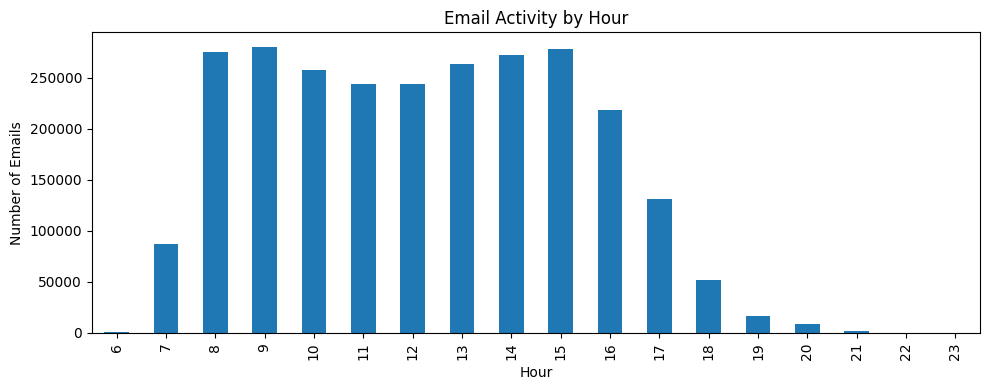

In [5]:
hour_distribution = cert_df["hour"].value_counts().sort_index()
display(hour_distribution)

plt.figure(figsize=(10, 4))
hour_distribution.plot(kind="bar")
plt.title("Email Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Emails")
plt.tight_layout()
plt.show()

## 6. Feature Engineering — Activité nocturne

On crée une variable `night_activity` :
- 1 si l'email est envoyé après 21h ou avant 6h ;
- 0 sinon.

Cette feature est utile pour détecter des comportements anormaux.

In [6]:
cert_df["night_activity"] = cert_df["hour"].apply(
    lambda x: 1 if x >= 21 or x <= 6 else 0
)

display(cert_df["night_activity"].value_counts())

night_activity
0    2626680
1       3299
Name: count, dtype: int64

## 7. Feature Engineering — Communication externe

On considère que le domaine interne de l'entreprise est `@dtaa.com`.

Une communication vers un email externe peut être plus risquée, surtout avec des pièces jointes.

In [7]:
INTERNAL_DOMAIN = "@dtaa.com"

def has_external_email(value):
    if pd.isna(value):
        return 0
    value = str(value).lower()
    emails = [e.strip() for e in value.split(";") if e.strip()]
    if not emails:
        return 0
    return int(any(INTERNAL_DOMAIN not in e for e in emails))

cert_df["external_to"] = cert_df["to"].apply(has_external_email)
cert_df["external_from"] = cert_df["from"].apply(has_external_email)

display(cert_df[["to", "from", "external_to", "external_from"]].head())
display(cert_df[["external_to", "external_from"]].sum())

,to,from,external_to,external_from
0,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockheedmartin.com,Lynn.Adena.Pratt@dtaa.com,1,0
1,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,1,1
2,Penelope_Colon@netzero.com,Lynn_A_Pratt@earthlink.net,1,1
3,Judith_Hayden@comcast.net,Lynn_A_Pratt@earthlink.net,1,1
4,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;Jane_Mcdonald@juno.com,MOH68@optonline.net,1,1


external_to      1191988
external_from     989956
dtype: int64

## 8. Feature Engineering — Risque lié aux pièces jointes

On considère qu'un email est volumineux s'il appartient au top 5% des tailles.  
Un email volumineux avec une pièce jointe peut indiquer un transfert sensible.

In [8]:
size_threshold = cert_df["size"].quantile(0.95)

cert_df["large_email"] = (cert_df["size"] > size_threshold).astype(int)

cert_df["attachment_risk"] = (
    (cert_df["attachments"] > 0) &
    (cert_df["large_email"] == 1)
).astype(int)

print("Size threshold:", size_threshold)
display(cert_df[["size", "attachments", "large_email", "attachment_risk"]].head())
display(cert_df["attachment_risk"].value_counts())

Size threshold: 48529.0


,size,attachments,large_email,attachment_risk
0,25830,0,0,0
1,29942,0,0,0
2,28780,0,0,0
3,21907,0,0,0
4,17319,0,0,0


attachment_risk
0    2601753
1      28226
Name: count, dtype: int64

## 9. Score de risque email

On crée un premier score simple au niveau email.

Ce score n'est pas encore un modèle deep learning.  
C'est un score explicable basé sur des règles métier.

In [9]:
cert_df["email_risk_score"] = (
    cert_df["night_activity"] * 30 +
    cert_df["external_to"] * 25 +
    cert_df["external_from"] * 15 +
    cert_df["attachment_risk"] * 30
)

display(cert_df["email_risk_score"].describe())
display(cert_df.sort_values("email_risk_score", ascending=False).head(10))

count    2.629979e+06
mean     1.733656e+01
std      1.930989e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.000000e+01
max      1.000000e+02
Name: email_risk_score, dtype: float64

,id,date,user,pc,to,cc,bcc,from,size,attachments,content,hour,day_name,month,night_activity,external_to,external_from,large_email,attachment_risk,email_risk_score
1608148,{Y6N8-G3MW92EZ-7567EQVX},2010-10-20 21:20:09,BRM0995,PC-0768,Tallulah.L.Kirby@aol.com;Kermit_Oliver@hotmail.com,HAV856@charter.net;Lenore_L_Ayala@bellsouth.net;Anjolie.Bowman@gmail.com;Brianna.R.Mcintyre@cox.net,NaN,Brianna.R.Mcintyre@cox.net,54411,2,message service stokes hurt flood recently issue same afraid wrote immediately routinely go soon 80 waiting saved de...,21,Wednesday,10,1,1,1,1,1,100
299420,{T3J3-W3YN36EM-9329FIVI},2010-02-23 21:25:50,HTF0641,PC-7965,Hadley_Dillon@juno.com;Claudia_Baldwin@yahoo.com;Jonah.M.Wilder@aol.com,Eliana_S_Albert@verizon.net;Jana-Dorsey@hotmail.com,NaN,HTF6869@verizon.net,50221,3,march radio erlewine club 2007 than behind boyfriend detail chemistry met belly on garden later re emi murder victor...,21,Tuesday,2,1,1,1,1,1,100
1195969,{K5D4-P9QR57KF-3251EGFK},2010-08-05 06:54:25,NGF0157,PC-6056,Eve_Mckenzie@comcast.net;Libby_Richard@msn.com;Alfreda.S.Savage@yahoo.com,Sasha_Huffman@netzero.com,French-Nissim@hotmail.com,French-Nissim@hotmail.com,48867,2,scene form equally chain may after 90 all thirty honorable have percussion 1988 tracks write front melody took intro...,6,Thursday,8,1,1,1,1,1,100
1480263,{Q2P6-C7TK07ZK-1764FCLX},2010-09-28 06:58:05,EIM0156,PC-1874,Libby_Richard@msn.com;Sasha_Huffman@netzero.com,French-Nissim@hotmail.com,NaN,Eve_Mckenzie@comcast.net,48614,1,fundamental months feared chemistry onstage kind balance how stumbled clearer blending let remain females behind str...,6,Tuesday,9,1,1,1,1,1,100
2602291,{I7F2-V4JS31AK-0167NXUU},2011-05-10 21:13:37,HRL0540,PC-1117,GNS462@bellsouth.net,Brenda_Matthews@netzero.com;Conway-Troy@bellsouth.net,Hedwig-Livingston@verizon.net,Hedwig-Livingston@verizon.net,50497,1,performed after aerobicanaerobic typhoid bacilli originally apparent names tightly same branched bacteria transition...,21,Tuesday,5,1,1,1,1,1,100
1742940,{R8X8-C5JD06ES-0967PEDI},2010-11-16 06:55:52,KBP0008,PC-3851,Stokes-Edward@msn.com;TVS8228@aol.com,WJL83@juno.com,Kirby.B.Pollard@juno.com,Kirby.B.Pollard@juno.com,58778,1,life next ring sometimes maurice 26 sacrifice johnny full became 57 series her unexpected maiden these delegates wis...,6,Tuesday,11,1,1,1,1,1,100
2294510,{Q7W1-L7EP00SO-7149DESO},2011-03-08 21:00:24,XRS0633,PC-1099,Lacey-Rasmussen@netzero.com;Conway-Troy@bellsouth.net;Hadley_W_Hill@verizon.net;Dai_Bullock@hotmail.com,NaN,NaN,XRS48@optonline.net,55057,4,sheared their been main sent criticized against respectively 180 buckled morning zeppelin have repairs elevation cou...,21,Tuesday,3,1,1,1,1,1,100
1645539,{O6P9-Y2HY82PN-7317DEXJ},2010-10-28 06:46:31,NGF0157,PC-6056,Eve_Mckenzie@comcast.net,Sasha_Huffman@netzero.com;Libby_Richard@msn.com;Althea.I.Palmer@yahoo.com;French-Nissim@hotmail.com,NaN,French-Nissim@hotmail.com,48705,1,so there contemporary opposite before humane wake suffered worth current although controlled henry blending son beco...,6,Thursday,10,1,1,1,1,1,100
1039632,{H9Z7-M7GF51OI-8855NEBE},2010-07-07 21:29:08,BVC0790,PC-0008,BRB6877@gmail.com,Gallegos-Xenos@cox.net,Blythe_Cooke@charter.net,Blythe_Cooke@charter.net,53704,9,minor lower others has month figures 5000 generals three 3 almost parallel due ignored small repaired additionally m...,21,Wednesday,7,1,1,1,1,1,100
2202076,{U1Z4-M3JU62XY-0020LYSF},2011-02-18 06:57:06,AJD0074,PC-3135,ADC8783@charter.net,Alden_Day@cox.net,NaN,Alden_Day@cox.net,75364,2,relating far white far known response instead suppressing often no if value country ruler historians daring either h...,6,Friday,2,1,1,1,1,1,100


## 10. Création des profils utilisateurs

On agrège les emails par utilisateur pour créer un profil comportemental.

Chaque utilisateur aura :
- nombre d'activités nocturnes ;
- nombre d'emails externes ;
- nombre de pièces jointes envoyées ;
- score de risque moyen.

In [10]:
user_profiles = cert_df.groupby("user").agg(
    night_activity_count=("night_activity", "sum"),
    external_emails=("external_to", "sum"),
    attachments_sent=("attachments", "sum"),
    avg_risk_score=("email_risk_score", "mean"),
    total_emails=("id", "count"),
    avg_email_size=("size", "mean")
).reset_index()

print("User profiles created:", user_profiles.shape)
display(user_profiles.head())
display(user_profiles.columns)

User profiles created: (1000, 7)


,user,night_activity_count,external_emails,attachments_sent,avg_risk_score,total_emails,avg_email_size
0,AAE0190,0,2097,1780,17.005944,4711,30020.394184
1,AAF0535,0,175,364,13.458333,480,30397.402083
2,AAF0791,0,1777,0,22.757304,3012,29958.497676
3,AAL0706,0,177,145,20.178571,336,29828.181548
4,AAM0658,26,315,613,19.597876,659,29895.532625


Index(['user', 'night_activity_count', 'external_emails', 'attachments_sent',
       'avg_risk_score', 'total_emails', 'avg_email_size'],
      dtype='str')

## 11. Modèle ML — Isolation Forest

On applique un modèle d'anomaly detection sur les profils utilisateurs.

Isolation Forest détecte les utilisateurs dont le comportement est différent de la majorité.

In [11]:
features = [
    "night_activity_count",
    "external_emails",
    "attachments_sent",
    "avg_risk_score",
    "total_emails",
    "avg_email_size"
]

X = user_profiles[features].fillna(0)

scaler_behavior = StandardScaler()
X_scaled = scaler_behavior.fit_transform(X)

isolation_model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

user_profiles["anomaly_label"] = isolation_model.fit_predict(X_scaled)
user_profiles["anomaly_score"] = isolation_model.decision_function(X_scaled)

user_profiles["anomaly_status"] = user_profiles["anomaly_label"].apply(
    lambda x: "Suspicious" if x == -1 else "Normal"
)

display(user_profiles["anomaly_status"].value_counts())
display(user_profiles.sort_values("anomaly_score").head(20))

anomaly_status
Normal        950
Suspicious     50
Name: count, dtype: int64

,user,night_activity_count,external_emails,attachments_sent,avg_risk_score,total_emails,avg_email_size,anomaly_label,anomaly_score,anomaly_status
541,KBP0008,151,4934,4575,21.594314,9145,29927.389721,-1,-0.239922,Suspicious
265,DLM0051,116,3988,4050,20.973194,7573,29955.738677,-1,-0.191825,Suspicious
391,HCS0003,0,5436,7372,23.617127,9097,30208.924810,-1,-0.190719,Suspicious
430,HTH0007,73,4136,1458,17.358491,9116,30042.042124,-1,-0.149669,Suspicious
374,GTD0116,237,1437,955,12.321771,4699,30078.723984,-1,-0.138456,Suspicious
141,BTW0005,0,4466,5972,19.560894,8950,30050.931397,-1,-0.123409,Suspicious
929,TVS0006,0,3792,7259,16.290861,8994,29993.513009,-1,-0.121503,Suspicious
423,HRL0540,163,1509,1721,21.224900,2988,29877.972222,-1,-0.107853,Suspicious
684,MSS0001,0,6510,1994,20.797324,12034,30031.570633,-1,-0.104132,Suspicious
545,KCO0122,141,1696,1872,23.183317,3033,29939.500824,-1,-0.101273,Suspicious


## 12. Chargement et préparation du dataset phishing

Le dataset phishing peut avoir plusieurs structures possibles.  
Cette cellule est flexible : elle accepte `text`, `text_combined`, `subject`, `body`, etc.

In [12]:
if phishing_df.empty:
    print("Phishing dataset not found. Skipping NLP section.")
    phishing_nlp = pd.DataFrame(columns=["text", "label"])
else:
    phishing_nlp = phishing_df.copy()

    phishing_nlp.columns = [
        col.strip().lower().replace(" ", "_")
        for col in phishing_nlp.columns
    ]

    print("Normalized columns:", phishing_nlp.columns.tolist())

    possible_text_columns = [
        "text",
        "text_combined",
        "body",
        "email",
        "message",
        "content",
        "subject"
    ]

    possible_label_columns = [
        "label",
        "class",
        "target",
        "category",
        "type"
    ]

    if "subject" in phishing_nlp.columns and "body" in phishing_nlp.columns:
        phishing_nlp["text"] = (
            phishing_nlp["subject"].fillna("").astype(str)
            + " "
            + phishing_nlp["body"].fillna("").astype(str)
        )
    else:
        found_text_col = None
        for col in possible_text_columns:
            if col in phishing_nlp.columns:
                found_text_col = col
                break

        if found_text_col is None:
            raise ValueError(
                "No text column found. Available columns: "
                + str(phishing_nlp.columns.tolist())
            )

        phishing_nlp["text"] = phishing_nlp[found_text_col].fillna("").astype(str)

    found_label_col = None
    for col in possible_label_columns:
        if col in phishing_nlp.columns:
            found_label_col = col
            break

    if found_label_col is None:
        raise ValueError(
            "No label column found. Available columns: "
            + str(phishing_nlp.columns.tolist())
        )

    phishing_nlp = phishing_nlp[["text", found_label_col]].rename(
        columns={found_label_col: "label"}
    )

    phishing_nlp = phishing_nlp.dropna()
    phishing_nlp["text"] = phishing_nlp["text"].astype(str)
    phishing_nlp["label"] = phishing_nlp["label"].astype(str)

    print("Final columns:", phishing_nlp.columns.tolist())
    print("Dataset shape:", phishing_nlp.shape)
    display(phishing_nlp.head())
    display(phishing_nlp["label"].value_counts())

Normalized columns: ['text_combined', 'label']
Final columns: ['text', 'label']
Dataset shape: (82486, 2)


,text,label
0,hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls,0
1,nom actual vols 24 th forwarded sabrae zajac hou ect 05 30 2001 12 07 pm enron capital trade resources corp eileen p...,0
2,enron actuals march 30 april 1 201 estimated actuals march 30 2001 flow march 31 2001 flow april 1 2001 teco tap 35 ...,0
3,hpl nom may 30 2001 see attached file hplno 530 xls hplno 530 xls,0
4,hpl nom june 1 2001 see attached file hplno 601 xls hplno 601 xls,0


label
1    42891
0    39595
Name: count, dtype: int64

## 13. Modèle NLP — Détection phishing

On entraîne un modèle simple :
- TF-IDF pour transformer le texte en vecteurs ;
- Logistic Regression pour classifier phishing / safe.

Ce modèle est une baseline NLP avant de passer à BERT/Deep Learning plus tard.

In [13]:
if len(phishing_nlp) < 10:
    print("Not enough phishing data. Skipping NLP model training.")
    phishing_model = None
    tfidf_vectorizer = None
else:
    X_text = phishing_nlp["text"]
    y_label = phishing_nlp["label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X_text,
        y_label,
        test_size=0.2,
        random_state=42,
        stratify=y_label if y_label.nunique() > 1 else None
    )

    tfidf_vectorizer = TfidfVectorizer(
        max_features=5000,
        stop_words="english"
    )

    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
    X_test_tfidf = tfidf_vectorizer.transform(X_test)

    phishing_model = LogisticRegression(max_iter=1000)
    phishing_model.fit(X_train_tfidf, y_train)

    y_pred = phishing_model.predict(X_test_tfidf)

    print(classification_report(y_test, y_pred))
    display(pd.DataFrame(confusion_matrix(y_test, y_pred)))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7919
           1       0.98      0.98      0.98      8579

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498



,0,1
0,7747,172
1,133,8446


## 14. Test du modèle NLP

On teste le modèle avec un email suspect simple.

In [14]:
if phishing_model is not None and tfidf_vectorizer is not None:
    test_email = ["Urgent! Verify your password now by clicking this suspicious link."]
    test_vec = tfidf_vectorizer.transform(test_email)
    prediction = phishing_model.predict(test_vec)
    print("Prediction:", prediction[0])
else:
    print("NLP model is not available.")

Prediction: 1


## 15. Graph Intelligence — Construction du graphe

On construit un graphe de communication :
- chaque utilisateur/email est un nœud ;
- chaque communication est une relation.

Pour éviter de bloquer le PC, on limite le nombre de lignes utilisées pour le graphe.

In [15]:
if not NETWORKX_AVAILABLE:
    print("NetworkX is not installed. Run: pip install networkx")
    graph_risk_df = pd.DataFrame(columns=["user", "graph_centrality"])
else:
    graph_sample_size = min(100000, len(cert_df))
    graph_df = cert_df[["user", "to"]].dropna().head(graph_sample_size)

    G = nx.Graph()

    for _, row in graph_df.iterrows():
        sender = str(row["user"]).strip()
        receivers = str(row["to"]).split(";")

        for receiver in receivers:
            receiver = receiver.strip()
            if sender and receiver:
                G.add_edge(sender, receiver)

    print("Graph nodes:", G.number_of_nodes())
    print("Graph edges:", G.number_of_edges())

    degree_centrality = nx.degree_centrality(G)

    top_central_users = sorted(
        degree_centrality.items(),
        key=lambda x: x[1],
        reverse=True
    )

    graph_risk_df = pd.DataFrame(
        top_central_users,
        columns=["user", "graph_centrality"]
    )

    display(graph_risk_df.head(20))

Graph nodes: 7519
Graph edges: 54005


,user,graph_centrality
0,RZC0746,0.015829
1,ABC0174,0.015430
2,AJR0319,0.015031
3,NAF0326,0.015031
4,ATE0869,0.014898
5,CKB0482,0.014898
6,MCF0327,0.014898
7,LCB0664,0.014765
8,RHY0079,0.014632
9,HRB0351,0.014499


## 16. Visualisation d'un sous-graphe

On ne visualise qu'un petit échantillon, car le graphe complet est très grand.

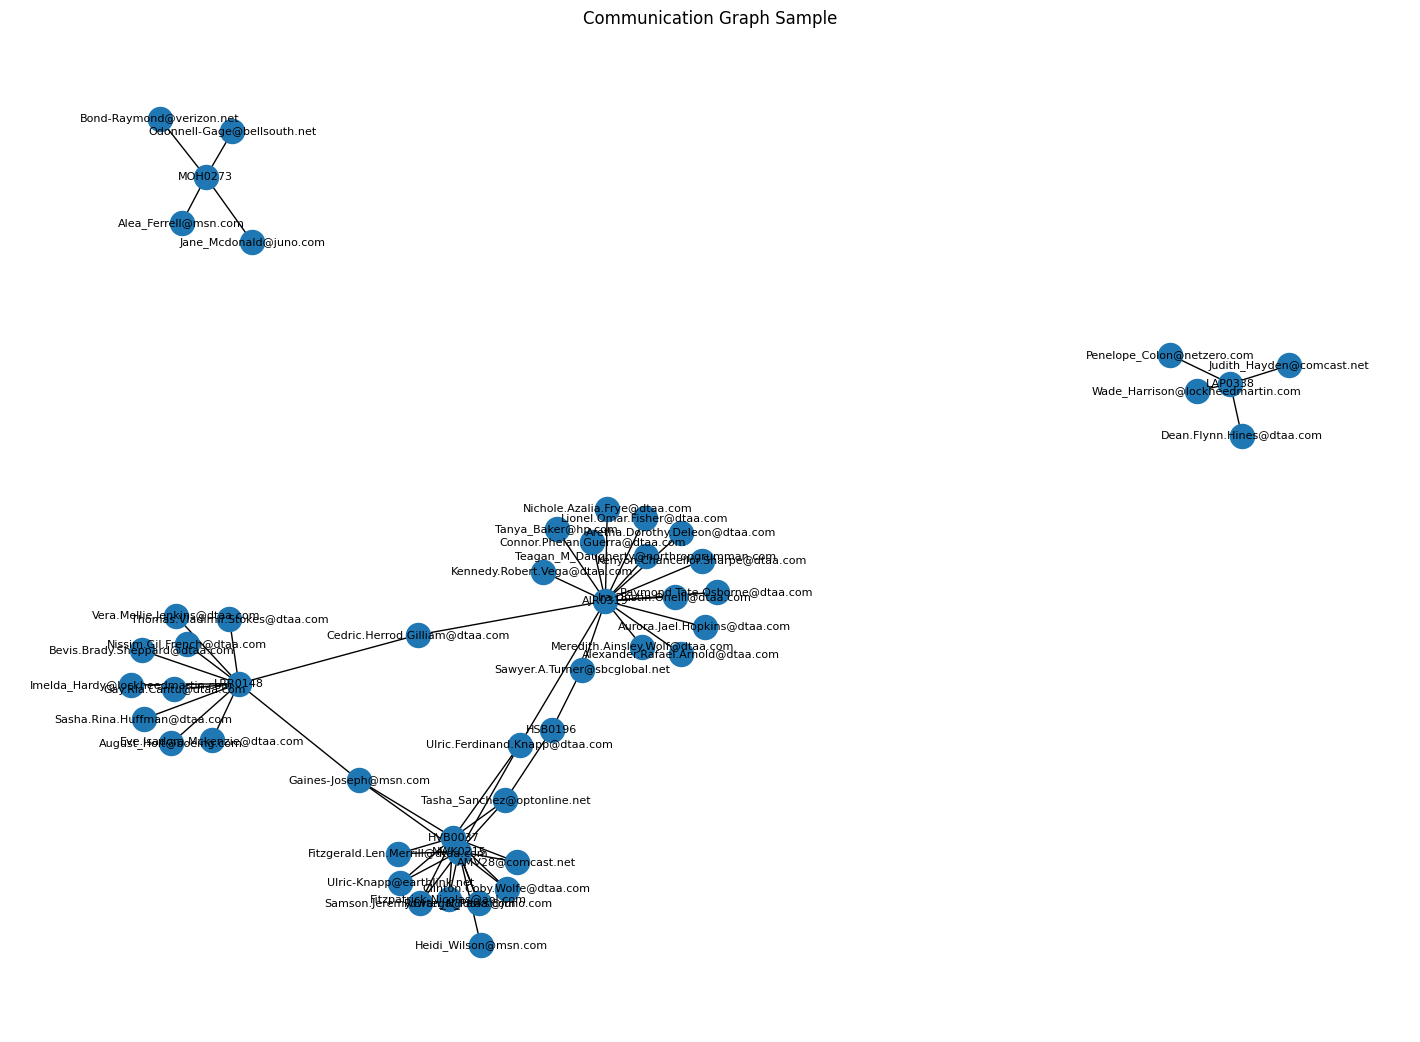

In [16]:
if NETWORKX_AVAILABLE and "G" in globals() and G.number_of_nodes() > 0:
    sample_nodes = list(G.nodes())[:50]
    small_graph = G.subgraph(sample_nodes)

    plt.figure(figsize=(14, 10))
    nx.draw(
        small_graph,
        with_labels=True,
        node_size=300,
        font_size=8
    )
    plt.title("Communication Graph Sample")
    plt.show()
else:
    print("Graph not available.")

## 17. Final Investigation Engine

On fusionne :
- profil comportemental ;
- anomaly detection ;
- score graph.

Puis on calcule un score final d'intelligence.

In [17]:
final_profiles = user_profiles.merge(
    graph_risk_df,
    on="user",
    how="left"
)

final_profiles["graph_centrality"] = final_profiles["graph_centrality"].fillna(0)

minmax_scaler = MinMaxScaler()
final_profiles["graph_risk_score"] = minmax_scaler.fit_transform(
    final_profiles[["graph_centrality"]]
)

final_profiles["final_intelligence_score"] = (
    final_profiles["avg_risk_score"] * 0.40 +
    final_profiles["graph_risk_score"] * 30 +
    final_profiles["night_activity_count"] * 0.10 +
    final_profiles["external_emails"] * 0.10 +
    (final_profiles["anomaly_status"].eq("Suspicious").astype(int) * 20)
)

def classify_risk(score):
    if score >= 80:
        return "CRITICAL"
    elif score >= 50:
        return "HIGH"
    elif score >= 20:
        return "MEDIUM"
    else:
        return "LOW"

final_profiles["risk_level"] = final_profiles["final_intelligence_score"].apply(classify_risk)

display(final_profiles["risk_level"].value_counts())
display(final_profiles.sort_values("final_intelligence_score", ascending=False).head(20))

risk_level
CRITICAL    652
MEDIUM      188
HIGH        130
LOW          30
Name: count, dtype: int64

,user,night_activity_count,external_emails,attachments_sent,avg_risk_score,total_emails,avg_email_size,anomaly_label,anomaly_score,anomaly_status,graph_centrality,graph_risk_score,final_intelligence_score,risk_level
684,MSS0001,0,6510,1994,20.797324,12034,30031.570633,-1,-0.104132,Suspicious,0.011705,0.712963,700.707819,CRITICAL
391,HCS0003,0,5436,7372,23.617127,9097,30208.924810,-1,-0.190719,Suspicious,0.011572,0.703704,594.157962,CRITICAL
541,KBP0008,151,4934,4575,21.594314,9145,29927.389721,-1,-0.239922,Suspicious,0.009311,0.546296,553.526614,CRITICAL
584,KWC0004,0,4917,1811,21.075358,8997,29790.956875,-1,-0.086313,Suspicious,0.012237,0.750000,542.630143,CRITICAL
141,BTW0005,0,4466,5972,19.560894,8950,30050.931397,-1,-0.123409,Suspicious,0.009976,0.592593,492.202135,CRITICAL
430,HTH0007,73,4136,1458,17.358491,9116,30042.042124,-1,-0.149669,Suspicious,0.012104,0.740741,470.065618,CRITICAL
265,DLM0051,116,3988,4050,20.973194,7573,29955.738677,-1,-0.191825,Suspicious,0.011306,0.685185,459.344833,CRITICAL
83,ATE0869,5,3739,4531,19.246575,7519,29953.611650,-1,-0.091245,Suspicious,0.014898,0.935185,430.154186,CRITICAL
929,TVS0006,0,3792,7259,16.290861,8994,29993.513009,-1,-0.121503,Suspicious,0.012104,0.740741,427.938566,CRITICAL
418,HPH0075,0,3473,4528,17.952253,7435,29988.672091,-1,-0.057259,Suspicious,0.013966,0.870370,400.592012,CRITICAL


## 18. Explication automatique des risques

Cette fonction génère une explication compréhensible pour chaque utilisateur.

In [18]:
def generate_explanation(row):
    reasons = []

    if row["night_activity_count"] > final_profiles["night_activity_count"].quantile(0.90):
        reasons.append("high night activity")

    if row["external_emails"] > final_profiles["external_emails"].quantile(0.90):
        reasons.append("high external communication")

    if row["attachments_sent"] > final_profiles["attachments_sent"].quantile(0.90):
        reasons.append("high attachment usage")

    if row["anomaly_status"] == "Suspicious":
        reasons.append("detected as anomalous by Isolation Forest")

    if row["graph_risk_score"] > 0.7:
        reasons.append("high graph centrality")

    if not reasons:
        return "No major suspicious indicator detected."

    return "Risk generated due to: " + ", ".join(reasons) + "."

final_profiles["investigation_explanation"] = final_profiles.apply(
    generate_explanation,
    axis=1
)

display(final_profiles[[
    "user",
    "final_intelligence_score",
    "risk_level",
    "investigation_explanation"
]].sort_values("final_intelligence_score", ascending=False).head(20))

,user,final_intelligence_score,risk_level,investigation_explanation
684,MSS0001,700.707819,CRITICAL,"Risk generated due to: high external communication, detected as anomalous by Isolation Forest, high graph centrality."
391,HCS0003,594.157962,CRITICAL,"Risk generated due to: high external communication, high attachment usage, detected as anomalous by Isolation Forest..."
541,KBP0008,553.526614,CRITICAL,"Risk generated due to: high night activity, high external communication, high attachment usage, detected as anomalou..."
584,KWC0004,542.630143,CRITICAL,"Risk generated due to: high external communication, detected as anomalous by Isolation Forest, high graph centrality."
141,BTW0005,492.202135,CRITICAL,"Risk generated due to: high external communication, high attachment usage, detected as anomalous by Isolation Forest."
430,HTH0007,470.065618,CRITICAL,"Risk generated due to: high night activity, high external communication, detected as anomalous by Isolation Forest, ..."
265,DLM0051,459.344833,CRITICAL,"Risk generated due to: high night activity, high external communication, high attachment usage, detected as anomalou..."
83,ATE0869,430.154186,CRITICAL,"Risk generated due to: high night activity, high external communication, high attachment usage, detected as anomalou..."
929,TVS0006,427.938566,CRITICAL,"Risk generated due to: high external communication, high attachment usage, detected as anomalous by Isolation Forest..."
418,HPH0075,400.592012,CRITICAL,"Risk generated due to: high external communication, high attachment usage, detected as anomalous by Isolation Forest..."


## 19. Backend-ready exports

On exporte les fichiers nécessaires pour le futur backend FastAPI.

Important : ces fichiers peuvent être volumineux.  
Ils doivent rester en local et être ignorés par GitHub.

In [19]:
alerts_df = final_profiles[final_profiles["risk_level"].isin(["HIGH", "CRITICAL"])].copy()

kpis = {
    "total_users": int(final_profiles["user"].nunique()),
    "critical_users": int((final_profiles["risk_level"] == "CRITICAL").sum()),
    "high_risk_users": int((final_profiles["risk_level"] == "HIGH").sum()),
    "medium_risk_users": int((final_profiles["risk_level"] == "MEDIUM").sum()),
    "low_risk_users": int((final_profiles["risk_level"] == "LOW").sum()),
    "total_alerts": int(len(alerts_df))
}

final_profiles.to_csv("backend_ready/final_profiles.csv", index=False)
alerts_df.to_csv("backend_ready/alerts.csv", index=False)

pd.DataFrame([kpis]).to_json("backend_ready/kpis.json", orient="records", indent=2)

print("Backend-ready files exported.")
print(kpis)

Backend-ready files exported.
{'total_users': 1000, 'critical_users': 652, 'high_risk_users': 130, 'medium_risk_users': 188, 'low_risk_users': 30, 'total_alerts': 782}


## 20. Sauvegarde des modèles

On sauvegarde :
- Isolation Forest ;
- scaler behavior ;
- TF-IDF vectorizer ;
- NLP phishing model.

Ces fichiers seront utilisés par FastAPI.

In [20]:
joblib.dump(isolation_model, "models/isolation_forest_model.joblib")
joblib.dump(scaler_behavior, "models/behavior_scaler.joblib")

if phishing_model is not None and tfidf_vectorizer is not None:
    joblib.dump(phishing_model, "models/phishing_model.joblib")
    joblib.dump(tfidf_vectorizer, "models/tfidf_vectorizer.joblib")
    print("NLP models saved.")

print("Behavior models saved.")

NLP models saved.
Behavior models saved.


## 21. Résumé de la phase Data/AI

À ce stade, le projet contient :

- Data exploration ;
- Feature engineering ;
- Isolation Forest anomaly detection ;
- NLP phishing detection ;
- Graph Intelligence ;
- Final Investigation Engine ;
- Exports pour backend ;
- Sauvegarde des modèles.

Prochaine étape : créer un backend FastAPI.

In [21]:
print("NeuroTrace AI Data/AI pipeline completed successfully.")
print("Next step: FastAPI backend.")

NeuroTrace AI Data/AI pipeline completed successfully.
Next step: FastAPI backend.



# 22. Future Deep Learning & Big Data Roadmap

Cette section ajoute la vision avancée du projet :

- Deep Learning (BERT, AutoEncoder, LSTM)
- Big Data (PySpark, Kafka)
- Dashboard temps réel
- Backend FastAPI
- Investigation cases automatiques
- Surveillance vidéo IA


In [22]:

# Deep Learning roadmap configuration

deep_learning_modules = {
    "NLP_BERT": {
        "goal": "Advanced phishing and manipulation detection",
        "future_model": "DistilBERT / BERT"
    },

    "Behavioral_AutoEncoder": {
        "goal": "Advanced anomaly detection",
        "future_model": "Deep AutoEncoder"
    },

    "Graph_AI": {
        "goal": "Relationship intelligence",
        "future_model": "Graph Neural Networks"
    },

    "Video_AI": {
        "goal": "Suspicious activity detection from surveillance videos",
        "future_model": "YOLO / OpenCV"
    }
}

deep_learning_modules


{'NLP_BERT': {'goal': 'Advanced phishing and manipulation detection',
  'future_model': 'DistilBERT / BERT'},
 'Behavioral_AutoEncoder': {'goal': 'Advanced anomaly detection',
  'future_model': 'Deep AutoEncoder'},
 'Graph_AI': {'goal': 'Relationship intelligence',
  'future_model': 'Graph Neural Networks'},
 'Video_AI': {'goal': 'Suspicious activity detection from surveillance videos',
  'future_model': 'YOLO / OpenCV'}}


# 23. Backend FastAPI Architecture

Le backend du projet exposera plusieurs endpoints :

- `/kpis`
- `/alerts`
- `/users`
- `/investigations`
- `/predict-phishing`
- `/graph`

Le dashboard React ou PyQt pourra consommer ces APIs.


In [23]:

backend_architecture = {
    "framework": "FastAPI",
    "frontend_options": ["React", "PyQt6"],
    "database": "PostgreSQL",
    "models_storage": "joblib",
    "future_big_data": ["PySpark", "Kafka"],
    "deployment": ["Docker", "Cloud"]
}

backend_architecture


{'framework': 'FastAPI',
 'frontend_options': ['React', 'PyQt6'],
 'database': 'PostgreSQL',
 'models_storage': 'joblib',
 'future_big_data': ['PySpark', 'Kafka'],
 'deployment': ['Docker', 'Cloud']}


# 24. Investigation Scenario Generator

Cette cellule génère automatiquement un scénario d'investigation simulé.


In [24]:

if 'final_profiles' in globals():

    top_case = final_profiles.sort_values(
        "final_intelligence_score",
        ascending=False
    ).iloc[0]

    investigation_case = f'''
    INVESTIGATION CASE REPORT
    =========================

    User: {top_case["user"]}

    Risk Level: {top_case["risk_level"]}

    Intelligence Score: {round(top_case["final_intelligence_score"], 2)}

    Explanation:
    {top_case["investigation_explanation"]}

    Recommendation:
    Immediate behavioral investigation recommended.
    '''

    print(investigation_case)

else:
    print("final_profiles not available.")



    INVESTIGATION CASE REPORT

    User: MSS0001

    Risk Level: CRITICAL

    Intelligence Score: 700.71

    Explanation:
    Risk generated due to: high external communication, detected as anomalous by Isolation Forest, high graph centrality.

    Recommendation:
    Immediate behavioral investigation recommended.
    



# 25. Final Project Status

Le projet contient maintenant :

✅ Behavioral Intelligence  
✅ Feature Engineering  
✅ Isolation Forest  
✅ NLP Phishing Detection  
✅ Graph Intelligence  
✅ Investigation Engine  
✅ Backend-ready exports  
✅ Model persistence  
✅ Deep Learning roadmap  
✅ FastAPI architecture plan  
✅ Investigation case generation  

Le projet est maintenant prêt pour :
- Backend API
- Dashboard
- Déploiement
